In [2]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

In [125]:
rp506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')
me506=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')

rp5061=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')
me5061=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')

rp5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200507/*geosgcm_prog.*200507*z.nc4')
me5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200507/*geosgcm_prog.*200507*z.nc4')

In [11]:
rp426=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0426/holding/geosgcm_prog/200504/*geosgcm_prog.*200504*z.nc4')
me426=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0426/holding/geosgcm_prog/200504/*geosgcm_prog.*200504*z.nc4')

rp4261=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0426/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')
me4261=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0426/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')

rp4262=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0426/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')
me4262=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0426/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')

In [12]:
rp426=xr.concat((rp426,rp4261,rp4262),dim='time')
me426=xr.concat((me426,me4261,me4262),dim='time')

In [126]:
me506=xr.concat((me506,me5061,me5062),dim='time')
rp506=xr.concat((rp506,rp5061,rp5062),dim='time')

In [127]:
# rp=rp.PS.compute()/100
# me=me.PS.compute()/100

In [128]:
# rp426=rp426.SLP.compute()/100
# me426=me426.SLP.compute()/100

rp506=rp506.SLP.compute()/100
me506=me506.SLP.compute()/100

In [129]:
rp506=rp506.sel(time=me506.time)

In [78]:
ME506P=xr.open_dataset(data+'ME506P.nc4').PRECTOT

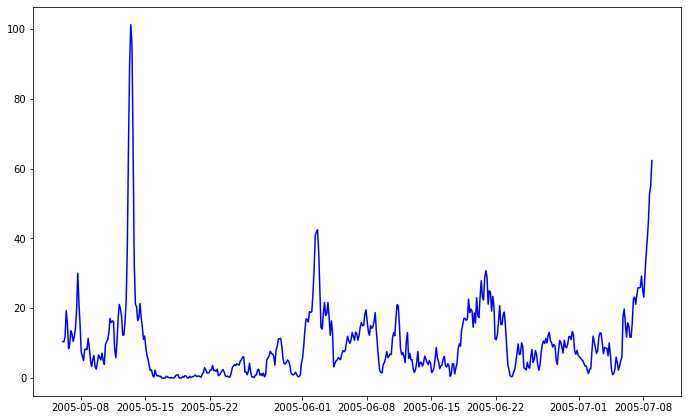

In [92]:

x1=-127
x2=-127
y1=7
y2=7


f()    
plt.plot(ME506P.time[:800],(ME506P[:800,:,:]).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')


In [131]:
idx=(ME506P.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']))
idx[idx>30]

<xarray.DataArray 'PRECTOT' (time: 20)>
array([ 30.03384434,  37.55059345,  66.28923006,  90.27820677,
       101.17377229,  95.60843334,  65.82674515,  32.87362223,
        30.92110567,  40.78822676,  41.84613694,  42.4328668 ,
        36.12314444,  30.75773399,  35.1392909 ,  39.76307893,
        44.95773241,  52.75107175,  55.12939822,  62.27237396])
Coordinates:
  * time     (time) datetime64[ns] 2005-05-07T16:30:00 ... 2005-07-08T22:30:00

In [87]:
time=array(['2005-05-13T12:00:00.000000000',],
      dtype='datetime64[ns]')

In [148]:
d=4
RP506=(rp506[:-d].data-rp506[d:])#.sel(lev=850)
ME506=(me506[:-d].data-me506[d:])#.sel(lev=850)

# d=4
# RP506= RP506.rolling(time=d).mean()
# ME506 = ME506.rolling(time=d).mean()


#RP506=RP506.resample(time='1D').mean()
#ME506=ME506.resample(time='1D').mean()

# RP506=RP506[d*2:-2*d,:,:]

# ME506=ME506[d*2:-2*d,:,:]

In [55]:
d=4
RP426=(rp426[:-d].data-rp426[d:])#.sel(lev=850)
ME426=(me426[:-d].data-me426[d:])#.sel(lev=850)

d=4
RP426= RP426.rolling(time=d).mean()
ME426 = ME426.rolling(time=d).mean()

In [56]:
# ME506=ME506
# RP506=RP506.sel(time=slice('2005-06-04','2005-06-15'))

In [57]:
# clf=arange(-2,2.1,.1)
# f()
# plt.subplot(2,1,1)
# ME506.sel(lat=slice(30,35)).mean(dim='lat').plot(levels=clf,cmap='coolwarm')
# plt.subplot(2,1,2)
# RP506.sel(lat=slice(30,35)).mean(dim='lat').plot(levels=clf,cmap='coolwarm')

In [58]:
# clf=arange(-2,2.1,.1)
# f()
# plt.subplot(2,1,1)
# plt.contourf(ME506.lon,ME506.time,ME506.sel(lat=slice(3,5)).mean(dim='lat'),levels=clf,cmap='coolwarm')
# plt.colorbar()
# plt.subplot(2,1,2)
# plt.contourf(ME506.lon,ME506.time,(ME506-RP506).sel(lat=slice(3,5)).mean(dim='lat'),levels=clf,cmap='coolwarm')
# plt.colorbar()

In [59]:
# rp=rp.resample(time='1D').mean()
# me=me.resample(time='1D').mean()

In [144]:
# RP506.data[RP506.data>0]=0
# ME506.data[ME506.data>0]=0

In [14]:
ME416C=zeros((181,360))
ME421C=zeros((181,360))
ME426C=zeros((181,360))
ME506C=zeros((181,360))
ME511C=zeros((181,360))

In [15]:
diff=(ME426-RP426)
for j in range(181):
    for i in range(360):
#         if nanmax(ME426P[:,j,i])>100:
#            if nanmax(ME426[:,j,i])<-2:
#                 if nanmax(ME511P[:,j,i])>100:
#                             if nanmax(RP426P[:,j,i])<50:
                                if nanmax(RP426[:,j,i])>-1:
                                        c=diff[:,j,i]
                                        ME426C[j,i]=len(c[c>nanmean(c)+4*nanstd(c)])
                                

In [63]:
# plot(ME506.std(dim='time')/ME506.mean(dim='time')-RP506.std(dim='time')/RP506.mean(dim='time'),clf=arange(-1,1.1,.1)*1e3);
nanmin(ME506)

-43.9841

In [91]:
# ME416C=zeros((181,360))
# ME421C=zeros((181,360))
# ME426C=zeros((181,360))
ME506C=zeros((181,360))
# ME511C=zeros((181,360))

diff=(ME506-RP506)
for j in range(181):
    for i in range(360):
#         if nanmax(ME506P[:,j,i])>100:
           if nanmin(ME506[:,j,i])<-2:
#                 if nanmax(ME511P[:,j,i])>100:
#                             if nanmax(RP506P[:,j,i])<50:
                               if nanmin(RP506[:,j,i])>-2:
                                        
                                        ME506C[j,i]=len(c[c<(nanmean(c)-1*nanstd(c))])
                                

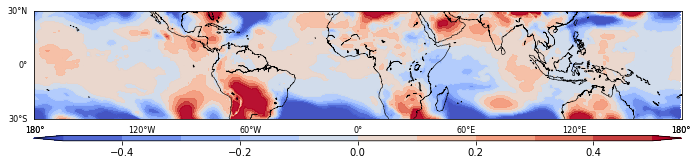

In [163]:
tt=idx[idx>20].resample(time='12h').mean().time
ME506.sel(time=tt)

clf=arange(-.5,.51,.1)
f()
# plt.subplot(2,2,1)
# plot(nanstd(ME506,0),ME506.lon,ME506.lat,cmap='coolwarm',lon1=-180,lon2=180,lat1=-30,lat2=30,clf=clf);

# plt.subplot(2,2,2)
# plot(nanstd(RP506,0),ME506.lon,ME506.lat,cmap='coolwarm',lon1=-180,lon2=180,lat1=-30,lat2=30,clf=clf);

# plt.subplot(2,2,3)
plot(nanstd(ME506,0)-nanstd(RP506,0),ME506.lon,ME506.lat,cmap='coolwarm',lon1=-180,lon2=180,lat1=-30,lat2=30,clf=clf);

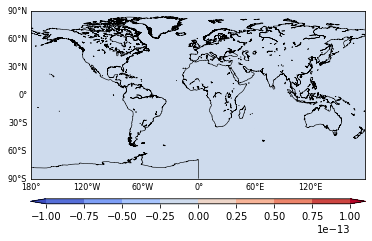

In [123]:
plot(nanmean(ME506,0)-nanmean(RP506,0),ME506.lon,ME506.lat,cmap='coolwarm');

In [146]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

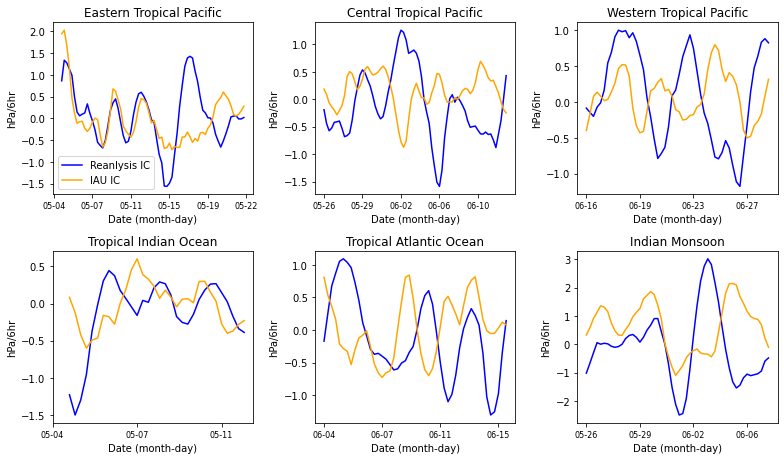

In [148]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-23',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-12')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-12')).time.data[i])[5:10])

# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')




ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-16','2005-06-28')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-16','2005-06-28')).time.data[i])[5:10])

    
plt.subplot(2,3,3)

x1=143
x2=143
y1=-1
y2=-1

plt.plot((ME506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8



ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-13',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-04','2005-06-15')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-04','2005-06-15')).time.data[i])[5:10])

    

plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-07')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-07')).time.data[i])[5:10])

    
plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
plt.savefig('spike_dpsdt.png',dpi=150)

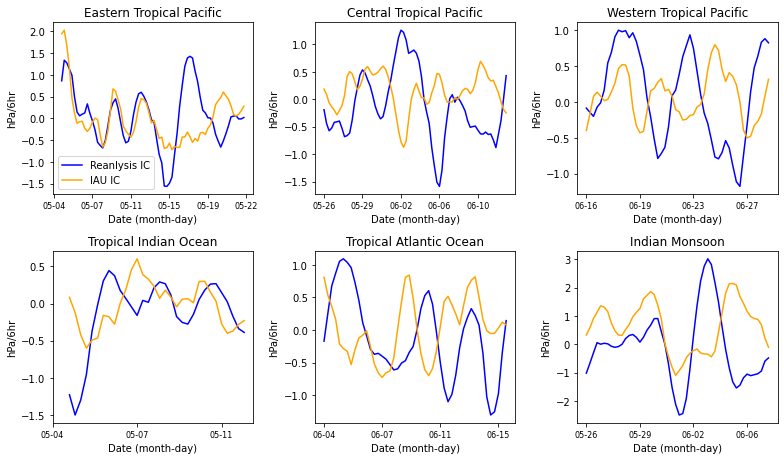

In [130]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-23',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-25'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-12')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-12')).time.data[i])[5:10])

# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-14'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')




ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-16','2005-06-28')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-16','2005-06-28')).time.data[i])[5:10])

    
plt.subplot(2,3,3)

x1=143
x2=143
y1=-1
y2=-1

plt.plot((ME506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506.sel(time=slice('2005-06-18','2005-06-30'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8



ticks=[]
dd=pd.date_range(start='2005-05-04', end='2005-05-13',freq='6H')

for i in range(len(dd)):
    ticks=append(ticks,str(dd[i])[5:10])
    
plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-06','2005-05-15'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-06-04','2005-06-15')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-06-04','2005-06-15')).time.data[i])[5:10])

    

plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-06-06','2005-06-17'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25


ticks=[]

for i in range(len(ME506.sel(time=slice('2005-05-26','2005-06-07')).time)):
    ticks=append(ticks,str(ME506.sel(time=slice('2005-05-26','2005-06-07')).time.data[i])[5:10])

    
plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506.sel(time=slice('2005-05-28','2005-06-9'))).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
#plt.savefig('spike_dpsdt.png',dpi=150)

In [131]:
import pandas as pd


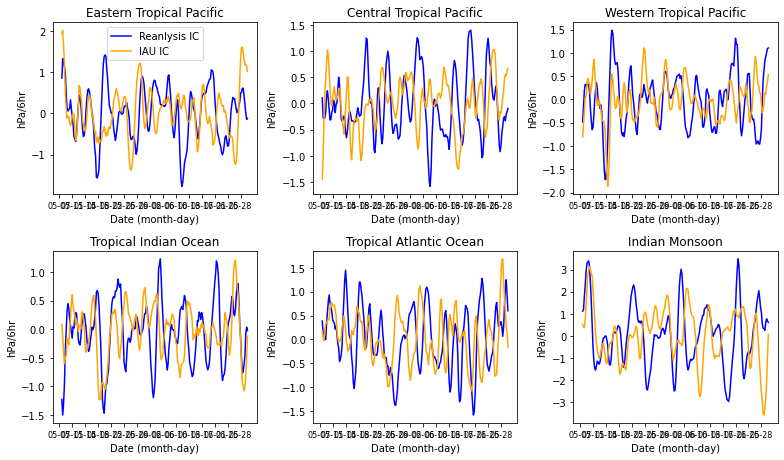

In [132]:

  
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))


plt.subplot(2,3,1)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=136
x2=137
y1=3
y2=5


plt.subplot(2,3,3)

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')


plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=89
x2=92
y1=7
y2=8


plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')

x1=90
x2=91
y1=23
y2=25



plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::15],ticks[::15],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('hPa/6hr')


plt.tight_layout()
plt.savefig('spike_dpsdt_full.png',dpi=150)

In [506]:
# for i in range(len(ME506.lat)):
#     for j in range(len(ME506.lon)):
#         if nanmax( vbnME506[:,i,j]

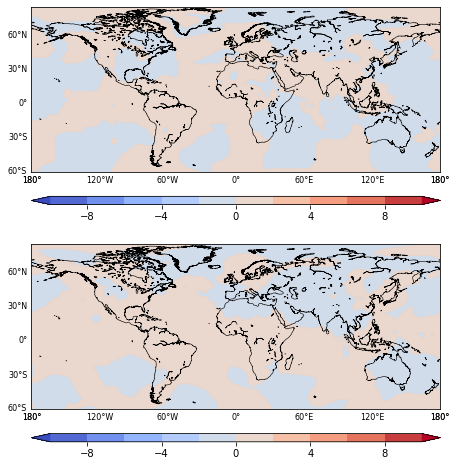

In [463]:
plt.figure(figsize=(8,8))
t=-1
plt.subplot(2,1,1)
plot(ME506[t,:,:]/100,lon1=-180,lon2=180,lat1=-60,lat2=85,clf=arange(-10,11,2));
plt.subplot(2,1,2)
plot((RP506[t,:,:]/100),clf=arange(-10,11,2),lon1=-180,lon2=180,lat1=-60,lat2=85);

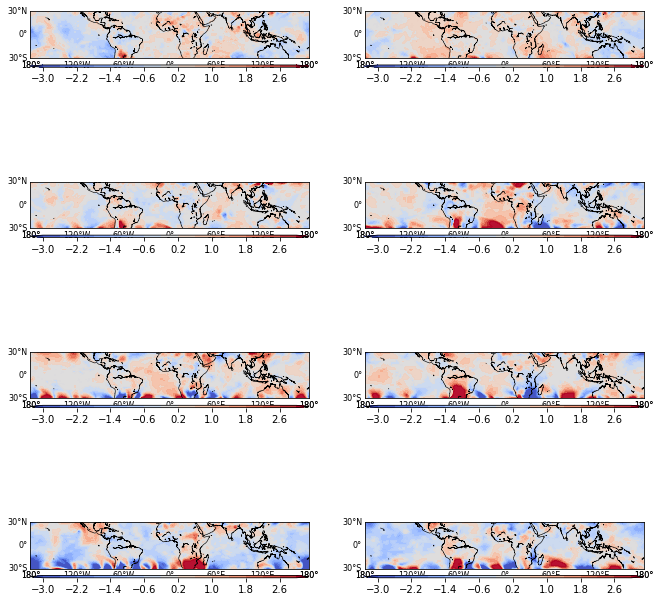

In [210]:
plt.figure(figsize=(11,12))

t=0
plt.subplot(4,2,1)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=2
plt.subplot(4,2,2)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=4
plt.subplot(4,2,3)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=24
plt.subplot(4,2,4)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);


t=30
plt.subplot(4,2,5)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);


t=33
plt.subplot(4,2,6)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=50
plt.subplot(4,2,7)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);

t=-1
plt.subplot(4,2,8)
plot(abs(ME506[t,:,:]/100)-abs(RP506[t,:,:]/100),clf=arange(-3,3.1,.4),lon1=-180,lon2=180,lat1=-30,lat2=30);